# 237. Delete Node in a Linked List
https://leetcode.com/problems/delete-node-in-a-linked-list/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Copy and Skip** | **O(1)** | **O(1)** | **Copy next node's value, skip next node** |

## Methodology

Since we are not given access to the head of the list, we cannot find the previous node. Instead, we **copy the value** from the next node into the current node, then **skip over** the next node by updating the current node's `next` pointer. This effectively "deletes" the current node by overwriting it with its successor. Works because the node to delete is guaranteed not to be the tail.

## Solutions

### C#

In [ ]:
// 237. Delete Node in a Linked List
// Time: O(1) | Space: O(1)
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int x) { val = x; }
}

public class Solution {
    public void DeleteNode(ListNode node) {
        node.val = node.next.val;
        node.next = node.next.next;
    }
}

### Python

In [ ]:
# 237. Delete Node in a Linked List
# Time: O(1) | Space: O(1)
class ListNode:
    def __init__(self, x):
        self.val = x
        self.next = None

class Solution:
    def deleteNode(self, node: ListNode) -> None:
        node.val = node.next.val
        node.next = node.next.next

### Go

In [ ]:
// 237. Delete Node in a Linked List
// Time: O(1) | Space: O(1)
type ListNode struct {
    Val  int
    Next *ListNode
}

func deleteNode(node *ListNode) {
    node.Val = node.Next.Val
    node.Next = node.Next.Next
}

### Rust

In [ ]:
// 237. Delete Node in a Linked List
// Time: O(1) | Space: O(1)
// Note: Rust's ownership model makes this problem unusual.
// LeetCode's Rust signature uses raw pointer manipulation.
#[derive(PartialEq, Eq, Clone, Debug)]
pub struct ListNode {
    pub val: i32,
    pub next: Option<Box<ListNode>>,
}

impl Solution {
    pub fn delete_node(node: &mut ListNode) {
        if let Some(next) = node.next.take() {
            node.val = next.val;
            node.next = next.next;
        }
    }
}

## Example Scenarios

### 1. Common Case — Delete Middle Node
**Input:** List `[4,5,1,9]`, delete node with value `5`

Copy the next node's value into the current node: `5` becomes `1`. Then skip the old next node. Result: `[4,1,9]`. The trick is we never actually remove the given node — we overwrite it.

### 2. Slightly Complex — Delete Near the End
**Input:** List `[4,5,1,9]`, delete node with value `1`

Node `1` copies `9` from its next, then points to null. Result: `[4,5,9]`. This works because the problem guarantees the node is never the tail.

### 3. Edge Case: Time Factor — Long List, Delete Second Node
**Input:** List `[1,2,3,...,10000]`, delete node with value `2`

Despite the list having $10^4$ nodes, deletion is $O(1)$ — we only touch the given node and its immediate successor. No traversal needed since we already have a reference to the node.

### 4. Edge Case: Space Factor — Only Two Nodes Remaining
**Input:** List `[4,5]`, delete node with value `4`

Copy `5` into node `4`, set next to null. The list becomes `[5]`. Space is $O(1)$ — no extra memory allocated. The original head node now holds the tail's value.

### 5. Almost-Impossible but Plausible — Delete with Maximum Values
**Input:** List `[-1000, 1000]`, delete node with value `-1000`

At the boundary of the constraint $-1000 \le \text{Node.val} \le 1000$. Copy `1000` into the first node, remove the second. The value range does not affect the algorithm — it is purely a copy-and-relink operation in $O(1)$.

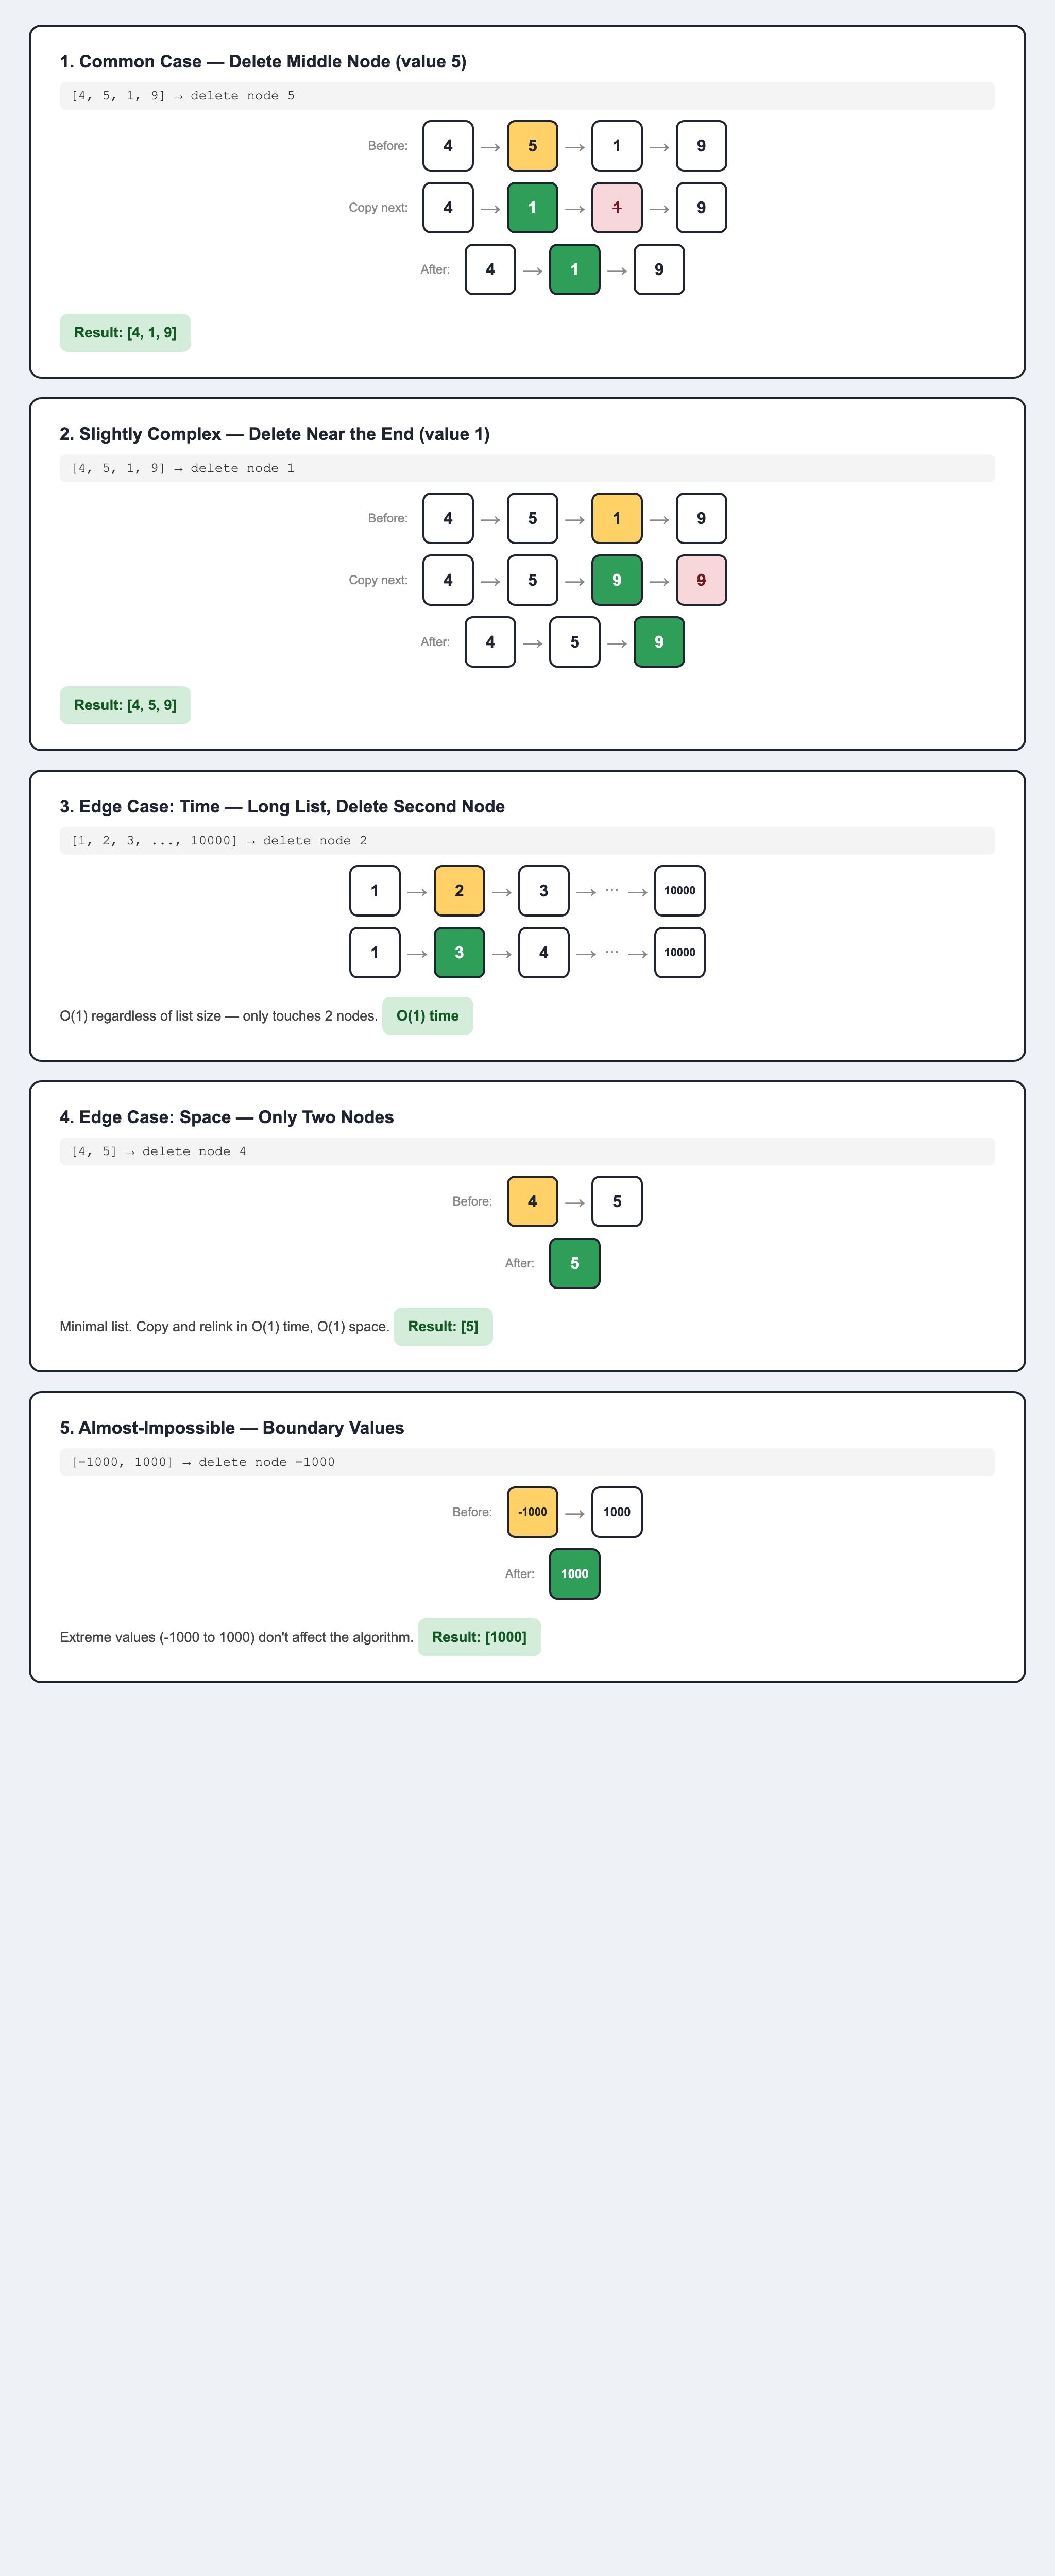